In [ ]:

import pandas as pd
# import re
# import emoji
# from pathlib import Path
# data_dir = Path('../data')
# resume_dataset=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/cleaned_combined_resume_final.csv')
resume_dataset=pd.read_csv('/content/drive/MyDrive/Projet MASTER1/cleaned_combined_resume_final.csv')

In [ ]:
#Lecture et affichage Information dataframme
def read_data(data,column_name):
    print("\n __Aperçu des données :")
    print(data.head(3))
    # Afficher les informations sur le DataFrame
    print("\n __Informations sur les données :")
    print(data.info())
    print(" \n __Taille : \n",data.shape)
    print("\n __Information sur les Categories: \n",data[column_name].value_counts().reset_index())


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
read_data(resume_dataset,'Category')


 __Aperçu des données :
   Unnamed: 0     Category                                             Resume
0           0  Other No IT  1. retail operations associate summary: suppor...
1           1  Other No IT  2. administrative database support specialist ...
2           2  Other No IT  3. office coordinator summary: responsible for...

 __Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9519 entries, 0 to 9518
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  9519 non-null   int64 
 1   Category    9519 non-null   object
 2   Resume      9519 non-null   object
dtypes: int64(1), object(2)
memory usage: 223.2+ KB
None
 
 __Taille : 
 (9519, 3)

 __Information sur les Categories: 
                                  Category  count
0                   Network Administrator   1056
1                        Security Analyst    915
2                      Software Developer    853
3    

### Echantillonnage

In [ ]:
import numpy as np

# Charger les données
resume_dataset=resume_dataset.drop(columns=['Unnamed: 0'])

# Calculer la fréquence des catégories
category_counts = resume_dataset['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Définir les seuils
threshold_min = 150
threshold_rare = 257

# Initialiser un DataFrame vide pour stocker l'échantillon final
sampled_data = pd.DataFrame()

# Étape 1 : Prendre TOUTES les catégories rares (< 257 échantillons)
rare_categories = category_counts[category_counts['Count'] < threshold_rare]['Category']
for category in rare_categories:
    category_data = resume_dataset[resume_dataset['Category'] == category]
    sampled_data = pd.concat([sampled_data, category_data])

# Étape 2 : Pour les catégories fréquentes, échantillonner avec minimum 150
frequent_categories = category_counts[
    (category_counts['Count'] >= threshold_rare) |
    (category_counts['Count'] >= threshold_min)
]['Category']

remaining_samples = 6000 - len(sampled_data)

for category in frequent_categories:
    category_data = resume_dataset[resume_dataset['Category'] == category]

    # Calculer la proportion cible basée sur la fréquence relative
    proportion = len(category_data) / len(resume_dataset)
    target_samples = max(int(proportion * remaining_samples), threshold_min)

    # Prendre le minimum entre le target et le disponible
    n_samples = min(target_samples, len(category_data))

    # Échantillonner
    sampled_category = category_data.sample(n=n_samples, random_state=42)
    sampled_data = pd.concat([sampled_data, sampled_category])

# Étape 3 : Si le total dépasse 6000, ré-équilibrer
if len(sampled_data) > 6000:
    excess = len(sampled_data) - 6000
    # Réduire prioritairement les catégories les plus représentées
    large_categories = sampled_data['Category'].value_counts().index[:5]
    to_remove = pd.DataFrame()

    for cat in large_categories:
        if excess <= 0:
            break
        cat_data = sampled_data[sampled_data['Category'] == cat]
        n_remove = min(excess, len(cat_data) - threshold_min)
        if n_remove > 0:
            removed = cat_data.sample(n=n_remove, random_state=42)
            to_remove = pd.concat([to_remove, removed])
            excess -= n_remove

    sampled_data = sampled_data.drop(to_remove.index)

# Réinitialiser l'index
sampled_data = sampled_data.reset_index(drop=True)
no_sampled_data=resume_dataset.drop(sampled_data.index)

In [ ]:
print("Taille echantillon",len(sampled_data))
print("Taille Data restant",len(no_sampled_data))

Taille echantillon 5840
Taille Data restant 3679


In [ ]:
resume_dataset=sampled_data
read_data(sampled_data,'Category')


 __Aperçu des données :
                        Category  \
0  Oracle Database Administrator   
1  Oracle Database Administrator   
2  Oracle Database Administrator   

                                              Resume  
0  ability: over 4 years of experience as archite...  
1  ability: oracle database administration, datab...  
2  ability: oracle database administration, oracl...  

 __Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5840 entries, 0 to 5839
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5840 non-null   object
 1   Resume    5840 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB
None
 
 __Taille : 
 (5840, 2)

 __Information sur les Categories: 
                                  Category  count
0           Oracle Database Administrator    406
1                   Network Administrator    397
2      Project Manager,Software Developer    392
3        Se

### DATA PREPARATION

#### Label encoding : Category

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
resume_dataset['label'] = le.fit_transform(resume_dataset['Category'])
resume_dataset.head()

,Category,Resume,label
0,Oracle Database Administrator,ability: over 4 years of experience as archite...,16
1,Oracle Database Administrator,"ability: oracle database administration, datab...",16
2,Oracle Database Administrator,"ability: oracle database administration, oracl...",16
3,Oracle Database Administrator,"ability: database design, monitoring performan...",16
4,Oracle Database Administrator,"ability: oracle database administration, perfo...",16


#### Split Data Train/Test

In [ ]:
from sklearn.model_selection import train_test_split
#Seperation des donnees 80% apprentissage  et 20% test
X_train, X_test, y_train, y_test = train_test_split(resume_dataset['Resume'],resume_dataset['label'], test_size=0.2, random_state=42)

### Embeddings avec DistilBERT

#### Tokenisation

In [ ]:
#!pip install tensorflow transformers
#!pip install tf-keras

In [ ]:
#import tensorflow as tf
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=256, return_tensors="tf") #reduit 256/128
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=256, return_tensors="tf")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [ ]:
# Afficher les informations sur les tokens
print("=== Informations sur les tokens ===")
print(f"Nombre d'exemples d'entraînement: {len(X_train)}")
print(f"Nombre d'exemples de test: {len(X_test)}")

# Afficher les dimensions des encodings
print("\nDimensions des encodings d'entraînement:")
print(f"  input_ids: {train_encodings['input_ids'].shape}")
print(f"  attention_mask: {train_encodings['attention_mask'].shape}")

print("\nDimensions des encodings de test:")
print(f"  input_ids: {test_encodings['input_ids'].shape}")
print(f"  attention_mask: {test_encodings['attention_mask'].shape}")

# Décoder et afficher un exemple de séquence tokenisée
print("\nExemple de tokenisation:")
sample_text = X_train.iloc[0]
print(f"Texte original: {sample_text[:100]}...")  # Afficher les 100 premiers caractères
# Tokeniser le texte
sample_tokens = tokenizer.encode(sample_text, truncation=True, max_length=256)
print(f"Texte token: {sample_tokens[:100]}...")
# Décoder les tokens
decoded_tokens = tokenizer.decode(sample_tokens)

print("\nTokens décodés:")
print(decoded_tokens[:500] + "...")

=== Informations sur les tokens ===
Nombre d'exemples d'entraînement: 4672
Nombre d'exemples de test: 1168

Dimensions des encodings d'entraînement:
  input_ids: (4672, 256)
  attention_mask: (4672, 256)

Dimensions des encodings de test:
  input_ids: (1168, 256)
  attention_mask: (1168, 256)

Exemple de tokenisation:
Texte original: studio manager studio manager studio manager - yoga pod houston, tx work experience studio manager y...
Texte token: [101, 2996, 3208, 2996, 3208, 2996, 3208, 1011, 13272, 17491, 5395, 1010, 19067, 2147, 3325, 2996, 3208, 13272, 17491, 1011, 1996, 19268, 1010, 19067, 2418, 2000, 2556, 10670, 4818, 9273, 3388, 2008, 5260, 2154, 1011, 2000, 1011, 2154, 2996, 3136, 2000, 3424, 6895, 17585, 7396, 3791, 2096, 12725, 8335, 3737, 2011, 12771, 4248, 1998, 8114, 2578, 1012, 3625, 2005, 14357, 1998, 2731, 2996, 3095, 1012, 15389, 2015, 5541, 5821, 3488, 2000, 3298, 2996, 5618, 8010, 2011, 16401, 16746, 2000, 7846, 1012, 1029, 3445, 7396, 2918, 2011, 2423, 1999, 1017

#### Embedding

In [ ]:
import tensorflow as tf
from transformers import TFDistilBertModel
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)]
        )
        print("Mémoire GPU limitée à 8GB")
    except RuntimeError as e:
        print(f"Erreur configuration GPU: {e}")
model = TFDistilBertModel.from_pretrained('distilbert-base-uncased', use_safetensors=False)

# # Générer les embeddings
# # ###Generation direct
# # train_embeddings = model(train_encodings['input_ids']).last_hidden_state
# # test_embeddings = model(test_encodings['input_ids']).last_hidden_state

# ##Generation par lots
# batch_size = 16 #8  #16

# def generate_embeddings(encodings):
#     embeddings = []
#     for i in range(0, encodings['input_ids'].shape[0], batch_size):
#         batch = {
#             'input_ids': encodings['input_ids'][i:i+batch_size],
#             'attention_mask': encodings['attention_mask'][i:i+batch_size]
#         }
#         outputs = model(batch)
#         embeddings.append(outputs.last_hidden_state)
#     return tf.concat(embeddings, axis=0)

# train_embeddings = generate_embeddings(train_encodings)
# test_embeddings = generate_embeddings(test_encodings)

Erreur configuration GPU: Virtual devices cannot be modified after being initialized


tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_projector', 'vocab_layer_norm', 'activation_13', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the checkpoint was

#### **Libration d'espace :A Supprimer si on veur Enregistrer:**

##### AFFICHAGE EMBEDDING

In [ ]:

# # Afficher les informations principales
# print("=== Embeddings d'entraînement ===")
# print(f"Forme du tenseur : {train_embeddings.shape}")  # (nombre d'exemples, longueur séquence, dimension embedding)
# print(f"Type de données : {train_embeddings.dtype}")
# print("\nExtrait du premier embedding (premier exemple, premier token) :")
# print(train_embeddings[0, 0, :10].numpy())  # Affiche les 10 premières dimensions

# print("\n=== Embeddings de test ===")
# print(f"Forme du tenseur : {test_embeddings.shape}")
# print(f"Type de données : {test_embeddings.dtype}")
# print("\nExtrait du premier embedding (premier exemple, premier token) :")
# print(test_embeddings[0, 0, :10].numpy())

####  ENREGISTREMENT / CHARGEMENT TOKEN, EMBEDDING ET DONNEE SPLIT

##### Enregistrement

In [ ]:
# # AMETRE
# import numpy as np
# import joblib
# from pathlib import Path

# # Créer un dossier de sauvegarde
# save_dir = Path('/content/drive/MyDrive/Projet MASTER1/saved_data')
# save_dir.mkdir(exist_ok=True)

# # Sauvegarder les encodings
# np.save(save_dir / 'train_input_ids.npy', train_encodings['input_ids'].numpy())
# np.save(save_dir / 'train_attention_mask.npy', train_encodings['attention_mask'].numpy())
# np.save(save_dir / 'test_input_ids.npy', test_encodings['input_ids'].numpy())
# np.save(save_dir / 'test_attention_mask.npy', test_encodings['attention_mask'].numpy())

# # Sauvegarder les embeddings
# np.save(save_dir / 'train_embeddings.npy', train_embeddings.numpy())
# np.save(save_dir / 'test_embeddings.npy', test_embeddings.numpy())

# # Sauvegarder les étiquettes
# np.save(save_dir / 'y_train.npy', y_train.values)
# np.save(save_dir / 'y_test.npy', y_test.values)

# # Sauvegarder le LabelEncoder
# joblib.dump(le, save_dir / 'label_encoder.joblib')


##### Chargement

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import joblib
from pathlib import Path
import gc

# =====================================================================
# CONFIGURATION MÉMOIRE
# =====================================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)]
        )
        print("Mémoire GPU limitée à 8GB")
    except RuntimeError as e:
        print(f"Erreur configuration GPU: {e}")

# =====================================================================
# CHARGEMENT OPTIMISÉ DES DONNÉES
# =====================================================================
#save_dir = Path('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/saved_data')
save_dir = Path('/content/drive/MyDrive/Projet MASTER1/saved_data')
save_dir.mkdir(exist_ok=True, parents=True)

# Charger les encodings avec mmap
try:
    print("Chargement des encodings...")
    train_input_ids = np.load(save_dir/'train_input_ids.npy', mmap_mode='r')
    train_attention_mask = np.load(save_dir/'train_attention_mask.npy', mmap_mode='r')
    test_input_ids = np.load(save_dir/'test_input_ids.npy', mmap_mode='r')
    test_attention_mask = np.load(save_dir/'test_attention_mask.npy', mmap_mode='r')

    # Convertir directement en tenseurs TensorFlow
    print("Conversion en tenseurs TensorFlow...")
    train_encodings = {
        'input_ids': tf.convert_to_tensor(train_input_ids, dtype=tf.int32),
        'attention_mask': tf.convert_to_tensor(train_attention_mask, dtype=tf.int32)
    }

    test_encodings = {
        'input_ids': tf.convert_to_tensor(test_input_ids, dtype=tf.int32),
        'attention_mask': tf.convert_to_tensor(test_attention_mask, dtype=tf.int32)
    }

    # Libérer immédiatement les mmap numpy
    del train_input_ids, train_attention_mask, test_input_ids, test_attention_mask
    gc.collect()

    print("Chargement des embeddings...")
    # Charger les embeddings avec mmap et conversion directe
    train_embedding = np.load(save_dir/'train_embeddings.npy', mmap_mode='r')
    test_embedding = np.load(save_dir/'test_embeddings.npy', mmap_mode='r')

    # Convertir en float16 et en tenseur
    train_embeddings = tf.convert_to_tensor(train_embedding.astype(np.float16))
    test_embeddings = tf.convert_to_tensor(test_embedding.astype(np.float16))

    del train_embedding, test_embedding
    gc.collect()

    print("Chargement des labels...")
    y_train = np.load(save_dir/'y_train.npy')
    y_test = np.load(save_dir/'y_test.npy')

    print("Chargement du LabelEncoder...")
    le = joblib.load(save_dir/'label_encoder.joblib')

except Exception as e:
    print(f"Erreur de chargement: {e}")
    # Nettoyage complet en cas d'erreur
    variables = list(locals().keys())
    for var in variables:
        if var not in ['save_dir', 'e']:
            del locals()[var]
    gc.collect()
    raise

# =====================================================================
# VÉRIFICATION FINALE
# =====================================================================
print("\n=== CHARGEMENT RÉUSSI ===")
print("Train encodings:", {k: v.shape for k, v in train_encodings.items()})
print("Test encodings:", {k: v.shape for k, v in test_encodings.items()})
print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nExtrait du premier embedding (premier exemple, premier token) :")
print(train_embeddings[0, 0, :10])  # Affiche les 10 premières dimensions

print(test_embeddings[0, 0, :10])

Erreur configuration GPU: Virtual devices cannot be modified after being initialized
Chargement des encodings...
Conversion en tenseurs TensorFlow...
Chargement des embeddings...
Chargement des labels...
Chargement du LabelEncoder...

=== CHARGEMENT RÉUSSI ===
Train encodings: {'input_ids': TensorShape([4672, 256]), 'attention_mask': TensorShape([4672, 256])}
Test encodings: {'input_ids': TensorShape([1168, 256]), 'attention_mask': TensorShape([1168, 256])}
Train embeddings: (4672, 256, 768)
Test embeddings: (1168, 256, 768)
y_train: (4672,)
y_test: (1168,)

Extrait du premier embedding (premier exemple, premier token) :
tf.Tensor(
[-0.2465  -0.1392  -0.209    0.02217  0.0783  -0.0119   0.4146   0.1256
  0.05157 -0.4812 ], shape=(10,), dtype=float16)
tf.Tensor(
[-0.462    -0.163     0.004353 -0.0405    0.10834   0.2302    0.1761
  0.3484   -0.2734   -0.2515  ], shape=(10,), dtype=float16)


### MODELISATION

#### Modele Deep Learning

###### ***TEST ++ MODELS***

In [ ]:
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
from sklearn.utils import compute_class_weight
import numpy as np
import tensorflow as tf
import joblib
from pathlib import Path

# saveModel_dir=Path('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/saved_model')
saveModel_dir=Path('/content/drive/MyDrive/Projet MASTER1/saved_model')
saveModel_dir.mkdir(exist_ok=True, parents=True)

# Préparation des données
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Dimensions des données
input_shape = train_embeddings.shape[1:]  # (256, 768)

# Fonction pour créer le modèle CNN optimal
def create_cnn_model():
    model = Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))

    # Architecture CNN optimale
    model.add(Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    # Optimiseur avec configuration adaptée
    optimizer = Adam(
        learning_rate=0.0005,
        clipnorm=1.0,  # Empêche l'explosion des gradients
        beta_1=0.9,
        beta_2=0.999
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=saveModel_dir/"best_cnn_model_resume_classifier.weights.h5",
            save_best_only=True,
            monitor='val_accuracy',
            save_weights_only=True
        )
    ]

# Paramètres d'entraînement
BATCH_SIZE = 32
EPOCHS = 30

print("=== Entraînement CNN ===")
model = create_cnn_model()

# Afficher le résumé du modèle
model.summary()

# Vérifier la taille mémoire estimée
params = model.count_params()
print(f"Nombre de paramètres: {params:,}")
print(f"Estimation mémoire: {params * 4 / 1e6:.2f} MB (float32)")

# Calcul des poids de classe pour l'ensemble d'entraînement complet
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# Entraînement du modèle
history = model.fit(
    train_embeddings,
    y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

# Nettoyage de la mémoire
tf.keras.backend.clear_session()
gc.collect()

# Évaluation du modèle
test_loss, test_acc = model.evaluate(test_embeddings, y_test_cat)
y_pred = model.predict(test_embeddings)
y_pred_classes = np.argmax(y_pred, axis=1)

# Rapport de classification
print(f"\nAccuracy test: {test_acc:.4f}")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_, zero_division=0))

# Rapport de classification COMPLET (avec output_dict=True)
classification_report_dict = classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
metrics_data = []
for class_name in le.classes_:
    metrics_data.append({
        'class_name': class_name,
        'precision': classification_report_dict[class_name]['precision'],
        'recall': classification_report_dict[class_name]['recall'],
        'f1-Score': classification_report_dict[class_name]['f1-score'],
        'support': classification_report_dict[class_name]['support']
    })

# Création d'un DataFrame et sauvegarde en CSV
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(saveModel_dir / 'resume_class_metrics.csv', index=False)

# Sauvegarde du modèle complet (optionnel)
model.save(saveModel_dir/"CNN_final_model_classifier_resume.keras")
# Sauvegarder le LabelEncoder
joblib.dump(le, save_dir / 'label_encoder_resume.joblib')
print("Modèle CNN sauvegardé avec succès!")

=== Entraînement CNN ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 256, 128)       │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,985 (1.24 MB)

 Trainable params: 325,985 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Nombre de paramètres: 325,985
Estimation mémoire: 1.30 MB (float32)
Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.0756 - loss: 3.8759 - val_accuracy: 0.2991 - val_loss: 2.9464 - learning_rate: 5.0000e-04
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2741 - loss: 2.9542 - val_accuracy: 0.5064 - val_loss: 2.0819 - learning_rate: 5.0000e-04
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4294 - loss: 2.2114 - val_accuracy: 0.6474 - val_loss: 1.6016 - learning_rate: 5.0000e-04
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5617 - loss: 1.7484 - val_accuracy: 0.6966 - val_loss: 1.3947 - learning_rate: 5.0000e-04
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6325 - loss: 1.4297 - val_accuracy: 0.7051 - val_loss: 1.3084 - learning_rate: 5.0000e-04
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7118 - loss: 1.2502 - val_accuracy: 0.7372 - val_loss: 1.1298 - learning_rate: 

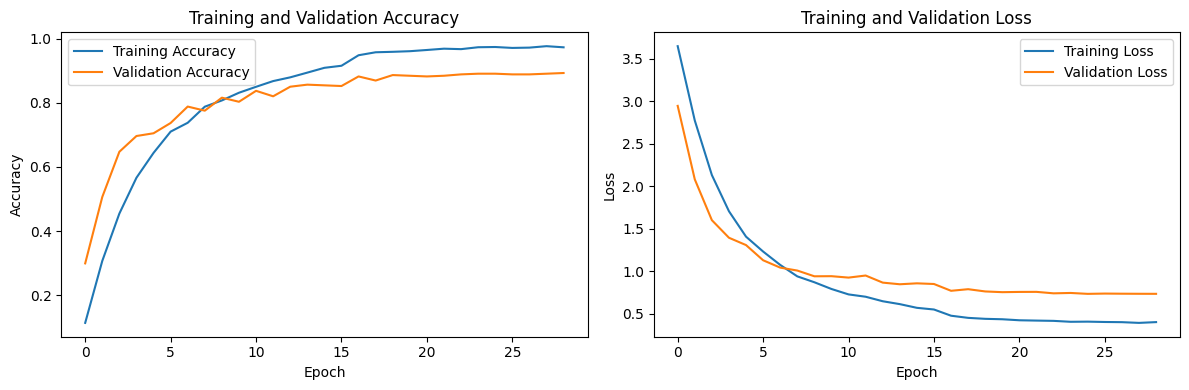

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# 2. Courbes d'apprentissage (Accuracy et Loss)
plt.figure(figsize=(12, 4))
# Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
# Sauvegarde des courbes d'apprentissage
plt.savefig(saveModel_dir / 'training_courbes.png', dpi=300, bbox_inches='tight')
plt.show()

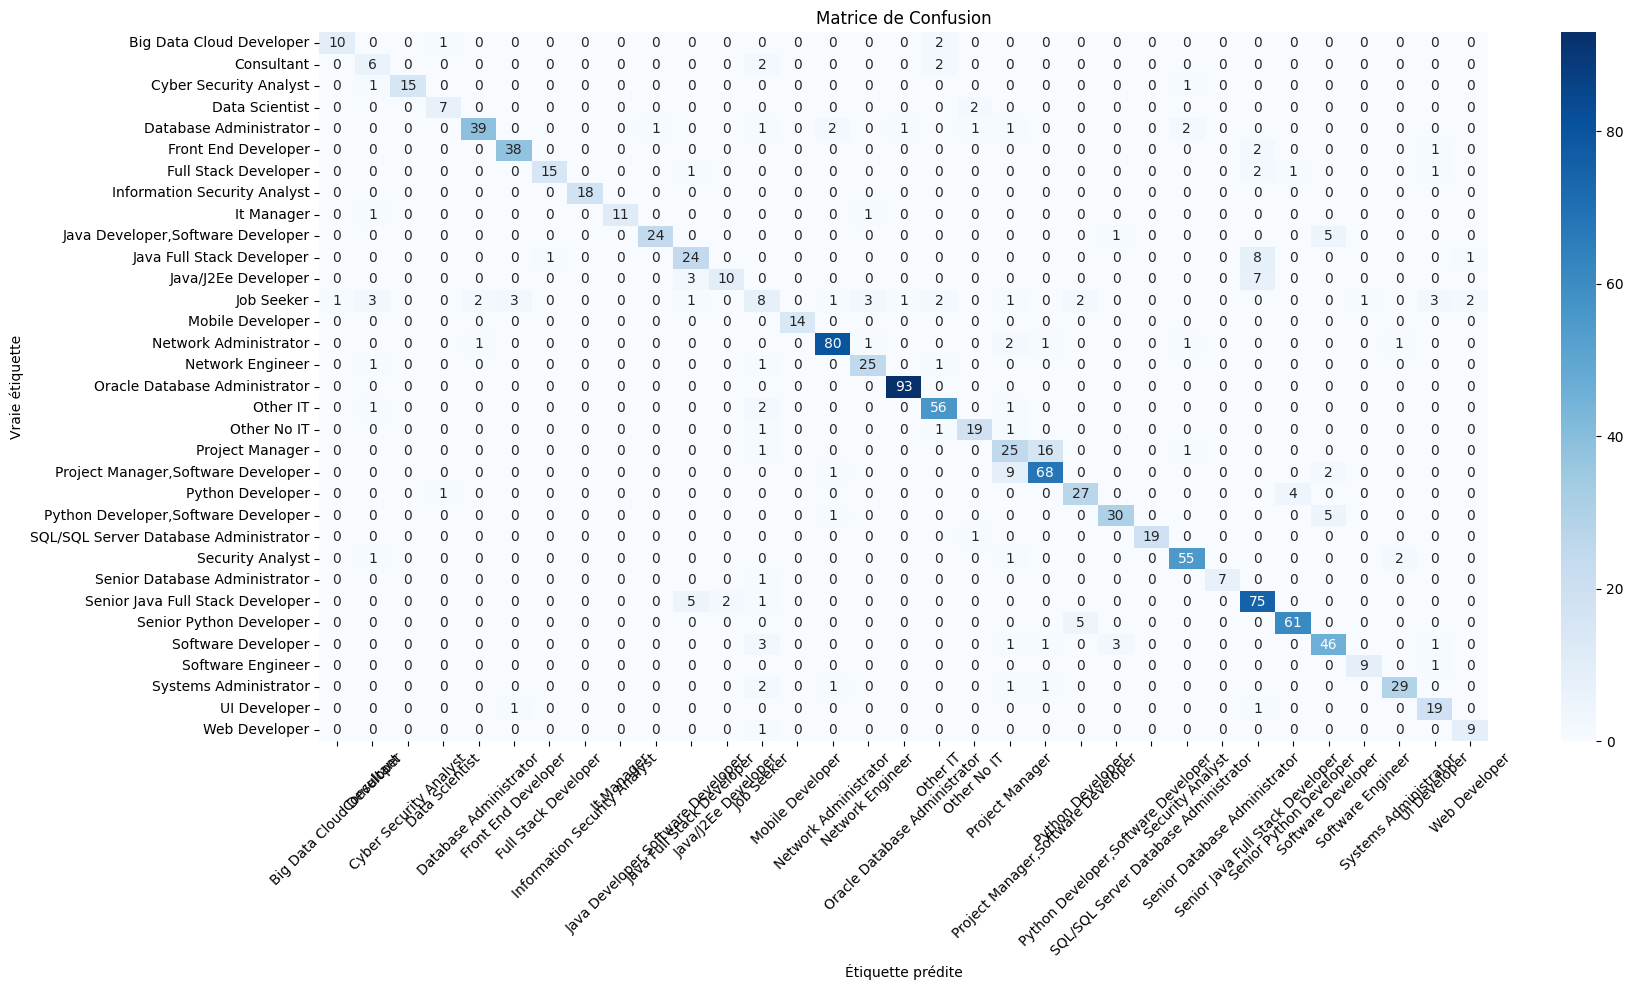

In [ ]:
plt.figure(figsize=(18, 10))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(saveModel_dir / 'confusion_matrix_seaborn.png', dpi=300, bbox_inches='tight')
plt.show()